# T56 — Rift obliquity through time: divergence velocity, extension vs strike-slip on plate boundaries

**Cluster B: Plate kinematics + tectonics.**

*Based on the method of:* Brune et al. (2012, *Nature Communications* 3, 1099), Brune et al. (2014, *Nature* 513, 456), Brune et al. (2016, *Geology* 44, 619), Brune et al. (2017, *Geology* 45, 1027 — "Oblique rifting: the rule, not the exception").

## What this notebook does

Divergence between rifting plates is rarely orthogonal to the rift trend. **Rift obliquity** — the angle α between the relative-velocity vector and the segment-normal direction — controls fault geometry, strain partitioning between extensional and strike-slip components, and ultimately the architecture of the resulting continental margin. Brune et al. (2017) showed that *oblique rifting is the rule, not the exception*: >70 % of the total length of extending plate boundaries over the last 230 Ma had α ≥ 20°.

This notebook implements the method:

1. Load a plate model + Continent-Ocean Boundary (COB) polygons per continental block.
2. For a pair of rifting plates (e.g. Africa 701 + South America 201), reconstruct both COB polygons to a snapshot age and find the segments where the two polygons share a boundary — these are the active rift edges at that age.
3. At each rift-edge midpoint compute the relative velocity between the two plates via a stage rotation, decompose into a **segment-orthogonal** component (extension rate) and a **segment-parallel** component (strike-slip rate), and derive obliquity α = arctan(v‖ / v⊥).
4. Filter out compressional segments and near-zero rates.
5. Repeat through time from 230 Ma to present at 5-Myr cadence → build **time-coded obliquity histograms** (Brune 2017 style), **rift-length time-series** and per-rift median obliquity curves.

**Default lead case**: South Atlantic (Africa 701 ↔ South America 201) at 130 Ma — rifting is active, obliquity is well-constrained by published geologic and geodynamic reconstructions.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.
**Runtime**: ~30 s per snapshot; ~5 min for the full 230-Myr sweep at 5-Myr cadence.


## Data availability

**COB polygon shapefile** — bundled with the tutorial suite at `data/rift_obliquity/brune_cob_polygons/SimplePolygons_inner.shp` (31 continental-block polygons keyed by `PLATEID1`, feature type `gpml:ClosedContinentalBoundary`). Provided by S. Brune (GFZ Potsdam), originally compiled for the Brune et al. (2016, 2017) analyses.

**Plate model** — Zahirovic 2022 (Z22) fetched via the Plate Model Manager on first run. Rotations for the plate IDs used by the shapefile (101, 201, 501, 701, 801, 802, and other standard EarthByte IDs) resolve cleanly in Z22.

**Coastlines** — fetched from Z22 via PMM.

## Sources

- Brune, S., Popov, A.A., Sobolev, S.V. (2012). Modeling suggests that oblique extension facilitates rifting and continental break-up. *Journal of Geophysical Research: Solid Earth* 117, B08402.
- Brune, S., Heine, C., Pérez-Gussinyé, M., Sobolev, S.V. (2014). Rift migration explains continental margin asymmetry and crustal hyper-extension. *Nature Communications* 5, 4014.
- Brune, S., Williams, S.E., Butterworth, N.P., Müller, R.D. (2016). Abrupt plate accelerations shape rifted continental margins. *Nature* 536, 201-204.
- Brune, S., Williams, S.E., Müller, R.D. (2017). Potential links between continental rifting, CO₂ degassing and climate change through time. *Nature Geoscience* 10, 941-946.
- Brune, S., Williams, S.E., Müller, R.D. (2018). Oblique rifting: the rule, not the exception. *Solid Earth* 9, 1187-1206.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize, LinearSegmentedColormap
import geopandas as gpd
from shapely.geometry import Polygon, LineString

import pygplates
import gplately
import pygmt
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, gpd, pygplates, gplately, pygmt):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  geopandas   1.0.1
  pygplates   1.0.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygmt       v0.18.0


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model + reference frame. Z22 in default mantle frame (anchor=0). The
# obliquity analysis is reference-frame invariant because it works on RELATIVE
# velocities between the two rifting plates; the anchor plate only affects
# the absolute positions the polygons get reconstructed to.
MODEL_NAME             = "Zahirovic2022"
ANCHOR_PLATE_ID        = 0

# COB polygon shapefile (bundled with the suite). Brune's method requires
# each pair of adjacent rift-flank polygons to *overlap* during active
# rifting — the shared-edge detection walks polygon A's boundary and asks
# "is the midpoint inside polygon B?", which only returns True inside the
# overlap zone. The `OuterPolygons_SouthAmericaUpdate.shp` set (34
# continental blocks) was digitised with this overlap deliberately built
# in for the rift ages of interest and is the file Sascha's original
# script uses. An `inner` variant is also bundled in the same folder but
# has NO overlap and gives zero segments — do not use it here.
COB_SHAPEFILE          = Path(
    "data/rift_obliquity/brune_cob_polygons/OuterPolygons_SouthAmericaUpdate.shp")

# Optional rotation-file override. Set to a .rot file path to use those
# rotations instead of MODEL_NAME's PMM rotations. Brune (2016)'s own
# rotation file is bundled at
# data/rift_obliquity/Brune_etal_GPlatesRotations_20160428_SB.rot and
# reproduces Sascha's original figures exactly (polygons overlap by
# design). MODEL_NAME's PMM rotations (Zahirovic 2022 default) work fine
# too — just raise POLYGON_BUFFER_DEG below to ~0.5-1° so the algorithm
# catches shared edges when polygons only *touch* rather than overlap.
USER_ROTATION_FILE     = None    # use MODEL_NAME (Z22 by default)

# Preset rift systems — plate-ID pair(s) that define each rift. Any pair can
# be added; the analysis loops over each pair inside the chosen system and
# accumulates segments. Keys are display labels; values are lists of
# (plateA, plateB) tuples. Choose one system by name for §3-§5; §6 sweeps
# through all of them for the multi-rift time series.
RIFT_SYSTEMS = {
    "South Atlantic":     [(701, 201)],                       # Africa - S. America
    "Australia-Antarctica": [(801, 802)],                      # Australia - E. Antarctica
    "North Atlantic":     [(101, 301), (102, 301), (102, 101)],  # NAm-Eur, Grn-Eur, Grn-NAm
    "India-Antarctica":   [(501, 802), (502, 802), (501, 801)],  # India - EAnt, SriLanka - EAnt, India - Aus
    "East African Rift":  [(701, 709)],                       # SAf - Somalia
    "Gulf of California": [(101, 105)],                       # NAm - Baja California
}

# The chosen rift system for §3-§5 (single-snapshot analysis + map + histogram).
RIFT_SYSTEM_NAME       = "South Atlantic"

# Snapshot age (Ma) for §3-§5. 130 Ma sits mid-rift for the South Atlantic
# (Africa-SAm rifting was active ~140-125 Ma, breakup ~125-110 Ma). Adjust
# to zoom into a different tectonic phase.
RECONSTRUCTION_TIME    = 130.0

# Buffer applied to polygon B (in degrees of lat/lon) before the point-in-
# polygon test that detects shared rift edges. Use 0 with Brune (2016)
# rotations + outer polygons (polygons overlap by design); raise to
# ~0.5-1.0° when using Zahirovic 2022 / Merdith 2021 / other rotation
# models — the polygons only "touch" at the rift with those rotations,
# so a small buffer catches the shared segments anyway.
POLYGON_BUFFER_DEG     = 0.5

# Sampling spacing along the reconstructed polygon boundaries (deg of
# planar lat/lon arc). Smaller = denser sampling, more rift segments,
# slower runtime. Shapefile vertices are ~1-2° apart; 1° interpolation
# gives modestly denser sampling without overloading the map.
SEGMENT_ARC_DEG        = 1.0

# Time window over which the velocity is estimated (Myr). 1 Myr matches the
# Brune workflow. Larger smooths across short-term stage-boundary jumps.
VELOCITY_WINDOW_MYR    = 1.0

# Filtering thresholds (from Brune's script). Segments with |v_orth| below
# this are treated as no-motion. Segments with v_orth > +compressionVelClip
# are compressional and excluded from the obliquity statistics.
CLIP_MIN_VEL_MM_YR     = 0.1
COMPRESSION_VEL_CLIP   = 0.5

# Obliquity binning (deg). Brune 2017 uses 5° bins for the histograms and
# time-coded surfaces.
OBLIQUITY_BIN_DEG      = 5

# Time sweep for §6-§7 (full-Phanerozoic-through-Cenozoic obliquity + rift-length).
AGE_MIN_MA             = 0
AGE_MAX_MA             = 230
AGE_STEP_MA            = 5
AGES_MA                = list(range(AGE_MIN_MA, AGE_MAX_MA + 1, AGE_STEP_MA))
# ============================================================================
print(f"  rift system: {RIFT_SYSTEM_NAME}  → plate pairs {RIFT_SYSTEMS[RIFT_SYSTEM_NAME]}")
print(f"  snapshot age: {RECONSTRUCTION_TIME:.0f} Ma")
print(f"  time sweep for §6/§7: {len(AGES_MA)} ages ({AGES_MA[0]}-{AGES_MA[-1]} Ma, step {AGE_STEP_MA} Myr)")

  rift system: South Atlantic  → plate pairs [(701, 201)]
  snapshot age: 130 Ma
  time sweep for §6/§7: 47 ages (0-230 Ma, step 5 Myr)


## 1. Load the plate model and COB polygons


In [3]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")

# Prefer the user-supplied rotation file (defaults to Brune 2016) so the
# COB polygon shapefile — which was digitised in that frame — resolves
# to overlapping polygons at the rift ages the algorithm needs. Fall
# back to MODEL_NAME's PMM rotations if the file is missing or the user
# explicitly set USER_ROTATION_FILE = None.
if USER_ROTATION_FILE is not None and USER_ROTATION_FILE.exists():
    rotation_model = pygplates.RotationModel(str(USER_ROTATION_FILE))
    _rot_src = f"user file: {USER_ROTATION_FILE.name}"
else:
    _pmm_rot = model.get_rotation_model()
    if not hasattr(_pmm_rot, "get_rotation"):
        rotation_model = pygplates.RotationModel(_pmm_rot)
    else:
        rotation_model = _pmm_rot
    _rot_src = f"{MODEL_NAME} via PMM"

recon = gplately.PlateReconstruction(
    rotation_model=rotation_model,
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  plate model loaded: {MODEL_NAME}, anchor {ANCHOR_PLATE_ID}")
print(f"  rotation source:    {_rot_src}")

# Load COB polygons and index by plate ID
if not COB_SHAPEFILE.exists():
    raise FileNotFoundError(
        f"COB polygon shapefile not found at {COB_SHAPEFILE}. Ensure the "
        "bundled data/rift_obliquity/brune_cob_polygons/ directory is present."
    )
cob_gdf = gpd.read_file(COB_SHAPEFILE)
print(f"  loaded {len(cob_gdf)} COB polygons from {COB_SHAPEFILE.name}")
print(f"  columns: {list(cob_gdf.columns)[:8]}...")

# Index by PLATEID1 for O(1) lookup
cob_by_plate = {int(row["PLATEID1"]): row for _, row in cob_gdf.iterrows()}
print(f"  plate IDs available: {sorted(cob_by_plate.keys())}")

# Verify the chosen rift system's plate pairs are all present
missing = [pid for pair in RIFT_SYSTEMS[RIFT_SYSTEM_NAME]
           for pid in pair
           if pid not in cob_by_plate]
if missing:
    raise ValueError(f"COB polygon missing for plate ID(s): {missing}. "
                      f"Available: {sorted(cob_by_plate.keys())}")
print(f"  ✓ all plate pairs for '{RIFT_SYSTEM_NAME}' have COB polygons")

  plate model loaded: Zahirovic2022, anchor 0
  rotation source:    Zahirovic2022 via PMM
  loaded 34 COB polygons from OuterPolygons_SouthAmericaUpdate.shp
  columns: ['PLATEID1', 'GPGIM_TYPE', 'TYPE', 'FROMAGE', 'TOAGE', 'NAME', 'DESCR', 'FEATURE_ID']...
  plate IDs available: [101, 102, 105, 201, 205, 283, 290, 301, 304, 331, 501, 502, 503, 602, 612, 613, 677, 701, 702, 709, 710, 714, 715, 801, 802, 804, 813, 833, 869, 890, 28800]
  ✓ all plate pairs for 'South Atlantic' have COB polygons


/opt/miniconda3/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: data/rift_obliquity/brune_cob_polygons/OuterPolygons_SouthAmericaUpdate.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
/opt/miniconda3/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
/opt/miniconda3/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Geometry of polygon of fid 2 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.


## 2. Helper functions — segment geometry, obliquity math

The core algorithm walks a polygon boundary, identifies segments whose midpoints also fall inside the *other* rift-flank polygon, and at each such shared-rift midpoint computes the relative velocity between the two plates and decomposes it into segment-normal + segment-parallel components. The geometry is done in **3-D Cartesian on the unit sphere** to avoid singularities near the poles / dateline; only the final quantities (lat, lon, velocity components, obliquity) are converted back to lat/lon at the end.


In [4]:
EARTH_RADIUS_KM = 6371.0

def _polygon_boundary_points(shapely_geom, arc_deg=None):
    """Return the ordered (lat, lon) points along the exterior boundary
    of a shapely polygon (or multipolygon). If arc_deg is set, interpolate
    intermediate points along the boundary using shapely's planar
    LineString.interpolate — this densifies the sampling for a much
    cleaner rift-obliquity map. If arc_deg is None, returns raw vertices."""
    if shapely_geom.geom_type == "MultiPolygon":
        out = []
        for poly in shapely_geom.geoms:
            out.extend(_polygon_boundary_points(poly, arc_deg))
        return out
    coords = list(shapely_geom.exterior.coords)
    if arc_deg is None or arc_deg <= 0:
        # Raw vertices only — shapefile order is (lon, lat)
        return [(float(lat), float(lon)) for lon, lat in coords]
    # Densify along shapely LineString (planar interpolation in lat/lon)
    from shapely.geometry import LineString
    ls = LineString(coords)
    total_len_deg = ls.length
    if total_len_deg <= 0:
        return [(float(lat), float(lon)) for lon, lat in coords]
    n_samples = max(len(coords), int(np.ceil(total_len_deg / arc_deg)))
    return [(pt.y, pt.x) for pt in
            (ls.interpolate(i * total_len_deg / n_samples)
             for i in range(n_samples + 1))]


def _reconstruct_polygon(shapely_geom, plate_id, age_ma):
    """Reconstruct a shapely polygon's exterior boundary to age_ma via
    pygplates rotation of plate_id. Returns a shapely Polygon in the
    reconstructed lat/lon frame."""
    rot = rotation_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=int(plate_id),
        from_time=0.0, anchor_plate_id=ANCHOR_PLATE_ID)
    if shapely_geom.geom_type == "MultiPolygon":
        from shapely.geometry import MultiPolygon
        return MultiPolygon([_reconstruct_polygon(p, plate_id, age_ma)
                              for p in shapely_geom.geoms])
    coords = []
    for lon, lat in shapely_geom.exterior.coords:
        pt = pygplates.PointOnSphere(float(lat), float(lon))
        rec_pt = rot * pt
        rla, rlo = rec_pt.to_lat_lon()
        coords.append((rlo, rla))
    return Polygon(coords)


def compute_rift_obliquity(cob_gdf, plate_pair, age_ma,
                            vel_window_myr=VELOCITY_WINDOW_MYR,
                            clip_min_vel=CLIP_MIN_VEL_MM_YR,
                            compression_clip=COMPRESSION_VEL_CLIP,
                            polygon_buffer_deg=POLYGON_BUFFER_DEG):
    """For a plate pair (pA, pB) at age_ma, return per-segment
    (mid_lat, mid_lon, v_orth_mm_yr, v_par_mm_yr, obliquity_deg,
    segment_length_km, class_str).

    Algorithm (based on Brune et al. 2017 method):
      1. Reconstruct COB polygons for pA and pB to age_ma (each via its
         own plate rotation — the polygons are attached to their host
         plates and move rigidly).
      2. Sample plate pA's boundary at ~arc_deg spacing. For each
         consecutive point pair, treat as a segment. Compute the segment
         midpoint in 3-D Cartesian.
      3. If the midpoint is INSIDE plate pB's reconstructed polygon,
         the segment is a shared-rift edge — otherwise skip.
      4. Compute the stage rotation of pB relative to pA over
         [age_ma+vel_window, age_ma] (from-time older, to-time younger,
         anchor=pA → relative motion of pB w.r.t. pA over the window).
      5. Apply the stage rotation to the midpoint to get the velocity
         vector in cartesian space (km/Myr → mm/yr).
      6. Build segment-parallel unit vector (t̂) along the segment and
         segment-normal unit vector (n̂ = t̂ × midpoint), and orient n̂ to
         point INTO plate pA's polygon.
      7. Project the velocity: v_orth = v · n̂ (extension is positive when
         pointing OUT of pA's polygon, so pA-inward n̂ makes extension
         v_orth < 0); v_par = |v · t̂|.
      8. Obliquity α = arctan2(|v_par|, |v_orth|), 0-90°.
      9. Filter: skip |v| < clip_min_vel; skip v_orth > +compression_clip
         (compressional).
    """
    pA, pB = plate_pair
    polyA_row = cob_gdf.get(pA)
    polyB_row = cob_gdf.get(pB)
    if polyA_row is None or polyB_row is None:
        return pd.DataFrame(columns=["mid_lat", "mid_lon", "v_orth_mm_yr",
                                      "v_par_mm_yr", "obliquity_deg",
                                      "seg_len_km", "class"])
    polyA_present = polyA_row["geometry"]
    polyB_present = polyB_row["geometry"]

    # Reconstruct both polygons to age_ma (each attached to its own plate)
    polyA_rec = _reconstruct_polygon(polyA_present, pA, age_ma)
    polyB_rec = _reconstruct_polygon(polyB_present, pB, age_ma)

    # Walk plate A's boundary — interpolated to SEGMENT_ARC_DEG for
    # denser sampling along the rift
    bdy = _polygon_boundary_points(polyA_rec, arc_deg=SEGMENT_ARC_DEG)
    if len(bdy) < 2:
        return pd.DataFrame(columns=["mid_lat", "mid_lon", "v_orth_mm_yr",
                                      "v_par_mm_yr", "obliquity_deg",
                                      "seg_len_km", "class"])

    # Optional buffer on polyB to catch shared edges when polygons only
    # *touch* rather than overlap (typical when using a rotation model
    # other than the one the polygons were digitised in).
    polyB_test = polyB_rec.buffer(polygon_buffer_deg) if polygon_buffer_deg > 0 else polyB_rec

    # Stage rotation of pB relative to pA over the velocity window
    stage_rot = rotation_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=int(pB),
        from_time=float(age_ma) + float(vel_window_myr),
        anchor_plate_id=int(pA))
    if stage_rot.represents_identity_rotation():
        # No motion → obliquity undefined; return empty
        return pd.DataFrame(columns=["mid_lat", "mid_lon", "v_orth_mm_yr",
                                      "v_par_mm_yr", "obliquity_deg",
                                      "seg_len_km", "class"])
    euler_pole, euler_angle = stage_rot.get_euler_pole_and_angle()
    pole_xyz = np.array([euler_pole.get_x(), euler_pole.get_y(),
                          euler_pole.get_z()])
    # velocity of a point r on pB relative to pA: v = ω × r, where
    # ω = (angle / dt) * pole_hat. dt = vel_window_myr.
    omega = pole_xyz * (euler_angle / vel_window_myr)   # rad/Myr along pole

    rows = []
    for i in range(len(bdy) - 1):
        laA, loA = bdy[i]
        laB, loB = bdy[i+1]
        ptA = pygplates.PointOnSphere(laA, loA)
        ptB = pygplates.PointOnSphere(laB, loB)
        ptA_xyz = np.array([ptA.get_x(), ptA.get_y(), ptA.get_z()])
        ptB_xyz = np.array([ptB.get_x(), ptB.get_y(), ptB.get_z()])
        seg_vec = ptB_xyz - ptA_xyz
        seg_len_arc = np.linalg.norm(seg_vec)
        if seg_len_arc < 1e-9:
            continue
        seg_len_km = seg_len_arc * EARTH_RADIUS_KM   # chord ≈ arc for small
        t_hat = seg_vec / seg_len_arc                # segment-parallel
        mid_xyz = 0.5 * (ptA_xyz + ptB_xyz)
        mid_xyz /= np.linalg.norm(mid_xyz)           # back to unit sphere
        mid_pt = pygplates.PointOnSphere(mid_xyz[0], mid_xyz[1], mid_xyz[2])
        mid_lat, mid_lon = mid_pt.to_lat_lon()

        # Is midpoint inside polygon B? — this identifies shared-rift edges
        # (segment on pA's boundary AND inside pB's polygon = the rift zone).
        # Use shapely contains on the reconstructed polygon (may fail for
        # antimeridian-crossing polygons; guard with try/except).
        try:
            if not polyB_test.contains(
                gpd.points_from_xy([mid_lon], [mid_lat])[0]):
                continue
        except Exception:
            continue

        # Segment-normal unit vector: n̂ = t̂ × mid, then choose sign so it
        # points INTO polyA (the plate whose boundary we're walking)
        n_hat = np.cross(t_hat, mid_xyz)
        n_norm = np.linalg.norm(n_hat)
        if n_norm < 1e-12:
            continue
        n_hat /= n_norm
        # Test which side is "inside polyA" — walk the test points a few
        # tens of km either side of the midpoint along ±n̂ so shapely can
        # reliably tell which side falls inside. (Sascha's original used
        # 3-D pygplates.PolygonOnSphere.is_point_in_polygon at 1e-9
        # displacement; shapely's 2-D planar containment is coarser and
        # needs a much larger displacement to distinguish sides.)
        eps = np.radians(0.5)   # ~55 km displacement, well-resolved by shapely
        plus_xyz  = mid_xyz + eps * n_hat
        minus_xyz = mid_xyz - eps * n_hat
        plus_xyz  /= np.linalg.norm(plus_xyz)
        minus_xyz /= np.linalg.norm(minus_xyz)
        plus_pt  = pygplates.PointOnSphere(plus_xyz[0],  plus_xyz[1],  plus_xyz[2])
        minus_pt = pygplates.PointOnSphere(minus_xyz[0], minus_xyz[1], minus_xyz[2])
        pla, plo = plus_pt.to_lat_lon()
        mla, mlo = minus_pt.to_lat_lon()
        try:
            plus_in  = polyA_rec.contains(gpd.points_from_xy([plo], [pla])[0])
            minus_in = polyA_rec.contains(gpd.points_from_xy([mlo], [mla])[0])
        except Exception:
            continue
        if plus_in and not minus_in:
            pass    # n̂ points into polyA — good
        elif minus_in and not plus_in:
            n_hat = -n_hat   # flip so n̂ points into polyA
        else:
            continue    # ambiguous → skip

        # Velocity of midpoint on plate pB relative to plate pA (km/Myr)
        vel_xyz = np.cross(omega, mid_xyz) * EARTH_RADIUS_KM   # km/Myr
        vel_mag = np.linalg.norm(vel_xyz)
        if vel_mag < clip_min_vel:
            continue
        v_orth = float(np.dot(vel_xyz, n_hat))   # +ve = compression (into pA)
        v_par  = abs(float(np.dot(vel_xyz, t_hat)))

        # Filter compressional
        if v_orth > compression_clip:
            continue

        # Obliquity: 0° for pure extension (v aligned with -n̂), 90° for pure
        # strike-slip. arctan2(|v_par|, |v_extension|).
        v_ext = -v_orth   # extension rate magnitude (may be small if oblique)
        obliq_rad = np.arctan2(v_par, max(v_ext, 1e-12))
        obliq_deg = float(np.degrees(obliq_rad))
        obliq_deg = min(obliq_deg, 90.0)

        cls = ("strike-slip"      if obliq_deg >= 60 else
                "oblique-rift"    if obliq_deg >= 20 else
                "orthogonal-rift")

        rows.append({
            "mid_lat":       float(mid_lat),
            "mid_lon":       float(mid_lon),
            "v_orth_mm_yr":  v_orth,
            "v_par_mm_yr":   v_par,
            "v_ext_mm_yr":   v_ext,
            "obliquity_deg": obliq_deg,
            "seg_len_km":    seg_len_km,
            "class":         cls,
        })

    return pd.DataFrame(rows)

print("✓ helpers defined: _resample_polygon_boundary, _reconstruct_polygon, compute_rift_obliquity")

✓ helpers defined: _resample_polygon_boundary, _reconstruct_polygon, compute_rift_obliquity


## 3. Compute obliquity for the chosen rift system at the snapshot age


In [5]:
def _polygon_diagnostic(pair, age_ma):
    """Diagnose why zero segments came back — reconstruct both polygons at
    age_ma and report their centroids + Shapely intersection area."""
    pA, pB = pair
    rA = _reconstruct_polygon(cob_by_plate[pA]["geometry"], pA, age_ma)
    rB = _reconstruct_polygon(cob_by_plate[pB]["geometry"], pB, age_ma)
    try:
        area_A = rA.area; area_B = rB.area
        inter_area = rA.intersection(rB).area if rA.is_valid and rB.is_valid else 0.0
    except Exception:
        area_A = area_B = inter_area = float("nan")
    cA = rA.centroid; cB = rB.centroid
    print(f"    pair {pA}-{pB} at {age_ma:.0f} Ma:")
    print(f"      plate {pA} centroid ({cA.x:+.1f}°, {cA.y:+.1f}°),  polygon area (sq-deg) ≈ {area_A:.1f}")
    print(f"      plate {pB} centroid ({cB.x:+.1f}°, {cB.y:+.1f}°),  polygon area (sq-deg) ≈ {area_B:.1f}")
    print(f"      intersection area (sq-deg) ≈ {inter_area:.2f}   "
          f"({'OVERLAP → shared edges expected' if inter_area > 0.1 else 'NO OVERLAP → no shared edges will be found'})")


frames = []
for pair in RIFT_SYSTEMS[RIFT_SYSTEM_NAME]:
    df = compute_rift_obliquity(cob_by_plate, pair, RECONSTRUCTION_TIME)
    df["plate_pair"] = f"{pair[0]}-{pair[1]}"
    frames.append(df)
snap_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

n = len(snap_df)
print(f"  {RIFT_SYSTEM_NAME} at {RECONSTRUCTION_TIME:.0f} Ma:")
print(f"    {n:,} rift-edge segments identified")
if n:
    total_km = float(snap_df["seg_len_km"].sum())
    print(f"    total rift length: {total_km:,.0f} km")
    med_obliq = float(snap_df["obliquity_deg"].median())
    print(f"    median obliquity: {med_obliq:.1f}°")
    med_ext  = float(snap_df["v_ext_mm_yr"].median())
    med_par  = float(snap_df["v_par_mm_yr"].median())
    print(f"    median extension rate: {med_ext:.1f} mm/yr")
    print(f"    median strike-slip rate: {med_par:.1f} mm/yr")
    print(f"    class distribution: "
          f"{snap_df['class'].value_counts().to_dict()}")
else:
    # Zero segments — run the polygon diagnostic + try a bracket of ages
    # so the user can see whether the rift is active at nearby times.
    print("\n  ⚠ Zero rift-edge segments — running polygon diagnostic:")
    for pair in RIFT_SYSTEMS[RIFT_SYSTEM_NAME]:
        _polygon_diagnostic(pair, RECONSTRUCTION_TIME)
    print("\n  scanning nearby ages for the FIRST pair to find any overlap:")
    _first_pair = RIFT_SYSTEMS[RIFT_SYSTEM_NAME][0]
    for _test_age in [80, 100, 120, 130, 140, 150, 160, 180, 200, 220]:
        _n = len(compute_rift_obliquity(cob_by_plate, _first_pair, float(_test_age)))
        _tag = "✓ has segments" if _n > 0 else "empty"
        print(f"    {_test_age:>4} Ma → {_n:>4} segments   {_tag}")
    print("\n  Choose an age from the ✓ rows above for RECONSTRUCTION_TIME "
          "and re-run this cell.")

  South Atlantic at 130 Ma:
    44 rift-edge segments identified
    total rift length: 4,603 km
    median obliquity: 13.2°
    median extension rate: 10.8 mm/yr
    median strike-slip rate: 2.7 mm/yr
    class distribution: {'orthogonal-rift': 32, 'oblique-rift': 12}


### How the algorithm identifies rift-edge segments and computes obliquity

For every plate pair in the chosen rift system:

1. Both COB polygons were reconstructed to the snapshot age via their own plate rotations.
2. Plate A's boundary was resampled at `SEGMENT_ARC_DEG` spacing.
3. Each segment was tested: is its midpoint inside plate B's reconstructed polygon? If yes, this is a shared rift edge.
4. Relative velocity between the two plates at the midpoint was computed from a 1-Myr stage rotation, decomposed into orthogonal (v⊥) and parallel (v‖) components relative to the segment.
5. Obliquity α = arctan(|v‖| / |v_ext|) — 0° = pure extension normal to the rift, 90° = pure strike-slip.
6. Compressional segments (v⊥ > 0.5 mm/yr into plate A) and near-motionless segments (|v| < 0.1 mm/yr) were dropped.

The class labels follow the Brune (2018) convention: **orthogonal** (α < 20°), **oblique** (20° ≤ α < 60°), **strike-slip** (α ≥ 60°).


## 4. Obliquity map at the snapshot age


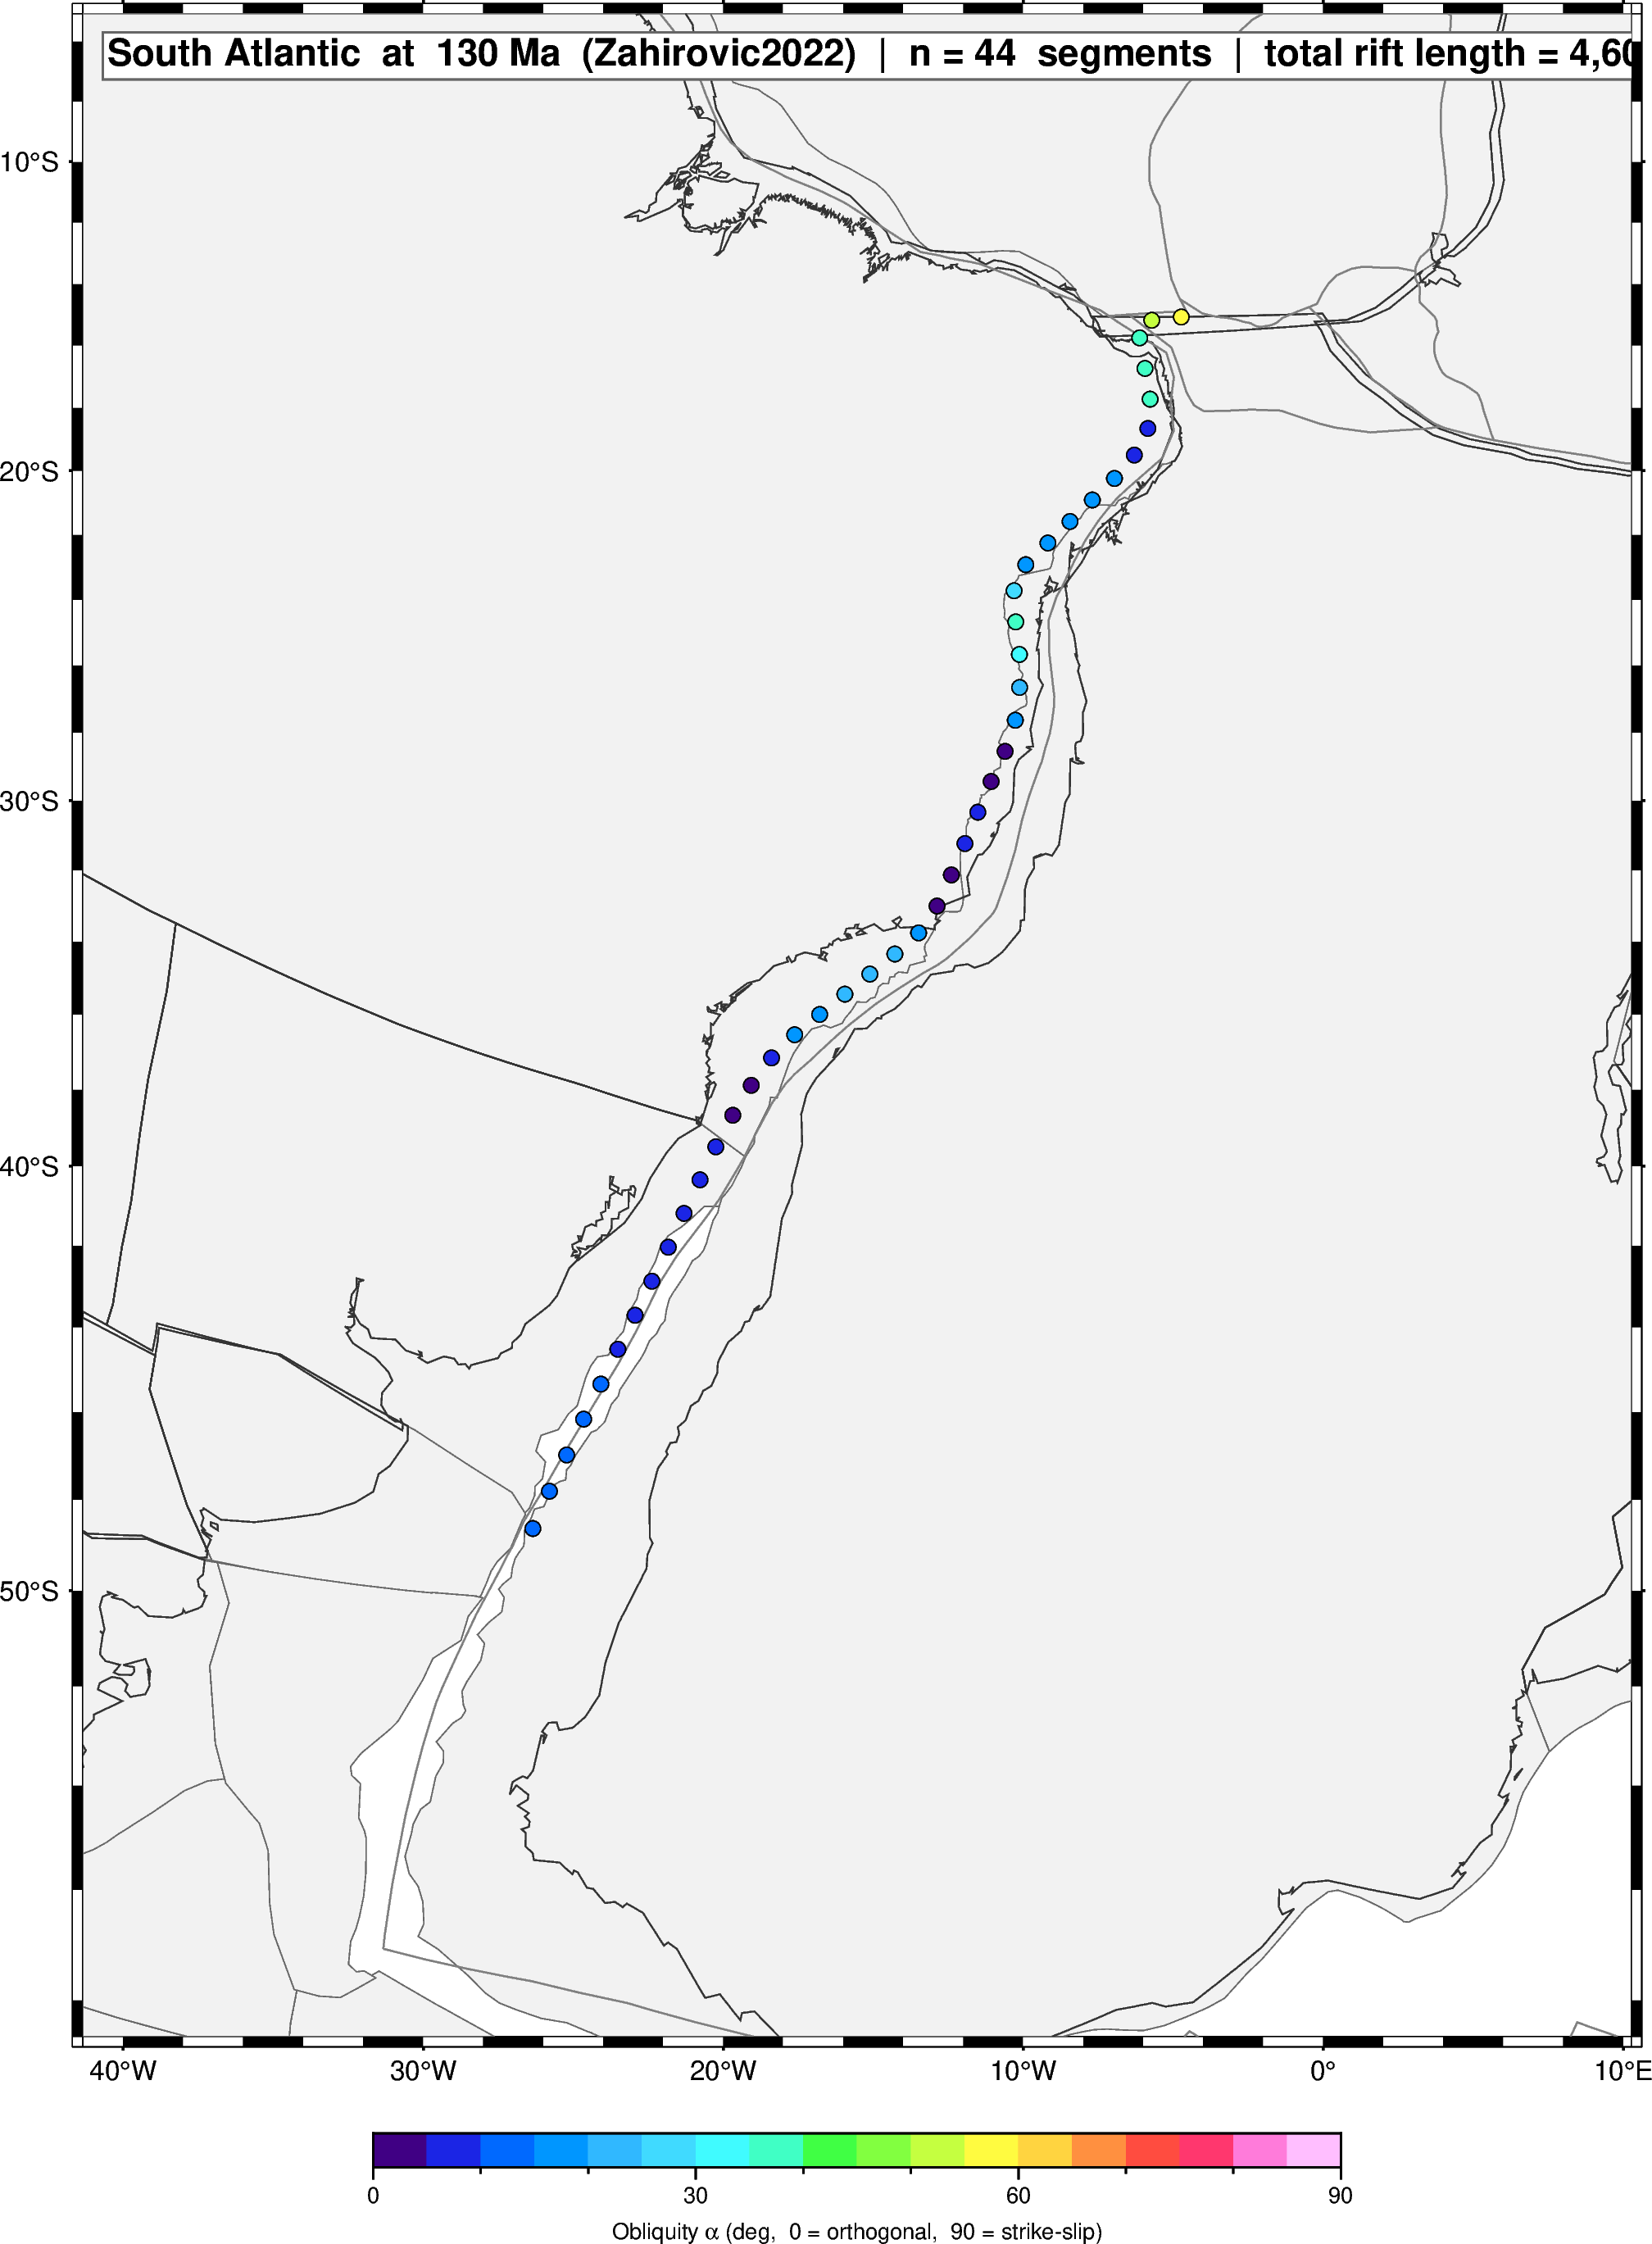

In [6]:
if snap_df.empty:
    raise RuntimeError("No rift-edge segments found — check that the plate "
                        "pair actually rifts at RECONSTRUCTION_TIME.")

# Build a PlotTopologies at the snapshot age for continent + coastline overlay
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(RECONSTRUCTION_TIME),
    plot_engine=gplately.PygmtPlotEngine(),
)

# Region — centred on the rift-edge midpoint distribution with a small margin.
_lon_min = float(snap_df["mid_lon"].min())
_lon_max = float(snap_df["mid_lon"].max())
_lat_min = float(snap_df["mid_lat"].min())
_lat_max = float(snap_df["mid_lat"].max())
_pad_lon = max(15, 0.15 * (_lon_max - _lon_min))
_pad_lat = max(10, 0.15 * (_lat_max - _lat_min))
region = [
    max(-180, _lon_min - _pad_lon),
    min( 180, _lon_max + _pad_lon),
    max( -85, _lat_min - _pad_lat),
    min(  85, _lat_max + _pad_lat),
]

fig = pygmt.Figure()
fig.basemap(region=region, projection="M16c", frame=["af", "WSne"])
try:
    gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
    gplot.plot_coastlines(fig, pen="0.4p,gray20")
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
except Exception as e:
    print(f"  (skip continent/backbone overlays: {type(e).__name__})")

# Obliquity dots — viridis 0-90°, size scales with extension rate
pygmt.makecpt(cmap="wysiwyg", series=[0, 90, 5], background="o")
# Size in cm proportional to extension rate (clamped); floor for visibility
sizes = 0.08 + 0.04 * np.clip(snap_df["v_ext_mm_yr"].abs(), 0, 30)
fig.plot(x=snap_df["mid_lon"], y=snap_df["mid_lat"],
          fill=snap_df["obliquity_deg"], cmap=True,
          style="c0.16c", pen="0.3p,black")
fig.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0/1c",
             frame=["xa30f10+lObliquity α (deg,  0 = orthogonal,  90 = strike-slip)"])
fig.text(text=(f"{RIFT_SYSTEM_NAME}  at  {RECONSTRUCTION_TIME:.0f} Ma  "
               f"({MODEL_NAME})  |  n = {len(snap_df):,}  segments  |  "
               f"total rift length = {snap_df['seg_len_km'].sum():,.0f} km"),
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="11p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=1100)

### How to read this map

Each dot is a rift-edge segment along plate A's reconstructed COB whose midpoint lies inside plate B's reconstructed COB. Colour = obliquity α; the viridis scale runs from **0° (orthogonal rift, dark purple)** through **~45° (moderate oblique, teal)** to **90° (pure strike-slip, yellow)**.

For the South Atlantic at 130 Ma you should see a broadly N-S trending rift with obliquity increasing southward (higher-α purple in the northern S. Atlantic vs greener/yellower dots south of Rio Grande Rise), consistent with Brune et al. (2014, 2017)'s central finding: the S. Atlantic rift was moderately oblique on average, with significant along-rift variation.


## 5. Obliquity histogram at the snapshot age


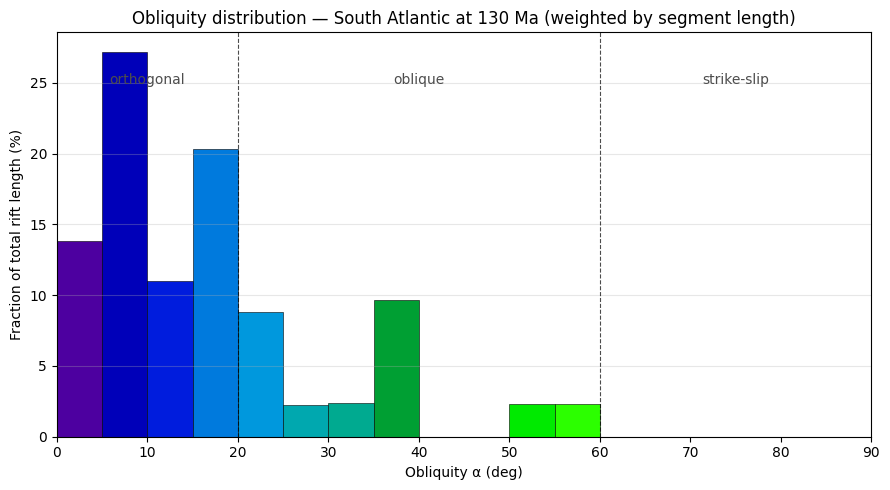

  Obliquity distribution: median 13.2°  (IQR 8.0°-20.4°)
    orthogonal-rift      3,329 km  ( 72.3%)
    oblique-rift         1,274 km  ( 27.7%)
    strike-slip              0 km  (  0.0%)


In [7]:
bins = np.arange(0, 90 + OBLIQUITY_BIN_DEG, OBLIQUITY_BIN_DEG)
hist, edges = np.histogram(snap_df["obliquity_deg"], bins=bins,
                            weights=snap_df["seg_len_km"])
# Bin percentages (of total rift length)
pct = 100 * hist / hist.sum() if hist.sum() > 0 else hist

fig, ax = plt.subplots(figsize=(9, 5))

bin_centres = 0.5 * (edges[:-1] + edges[1:])
# WYSIWYG-style rainbow (matplotlib's nipy_spectral is the closest visual
# analogue to GMT's wysiwyg — magenta/purple through blue-cyan-green to
# yellow-red — matching §4's pyGMT map cpt).
cmap_v = plt.cm.nipy_spectral
colors = cmap_v(0.1 + 0.8 * bin_centres / 90)   # 0.1-0.9 avoids the black tails
ax.bar(edges[:-1], pct, width=OBLIQUITY_BIN_DEG, align="edge",
       color=colors, edgecolor="black", linewidth=0.4)
# Class-boundary lines: orthogonal | oblique | strike-slip
ax.axvline(20, color="black", ls="--", lw=0.8, alpha=0.7)
ax.axvline(60, color="black", ls="--", lw=0.8, alpha=0.7)
ax.text(10, ax.get_ylim()[1] * 0.9, "orthogonal", ha="center", va="top",
         fontsize=10, color="0.3")
ax.text(40, ax.get_ylim()[1] * 0.9, "oblique",     ha="center", va="top",
         fontsize=10, color="0.3")
ax.text(75, ax.get_ylim()[1] * 0.9, "strike-slip", ha="center", va="top",
         fontsize=10, color="0.3")
ax.set_xlabel("Obliquity α (deg)")
ax.set_ylabel("Fraction of total rift length (%)")
ax.set_xlim(0, 90)
ax.set_title(f"Obliquity distribution — {RIFT_SYSTEM_NAME} at "
              f"{RECONSTRUCTION_TIME:.0f} Ma (weighted by segment length)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

med = float(snap_df["obliquity_deg"].median())
p25 = float(np.percentile(snap_df["obliquity_deg"], 25))
p75 = float(np.percentile(snap_df["obliquity_deg"], 75))
print(f"  Obliquity distribution: median {med:.1f}°  (IQR {p25:.1f}°-{p75:.1f}°)")
class_len_km = snap_df.groupby("class")["seg_len_km"].sum()
total = float(class_len_km.sum())
for k in ("orthogonal-rift", "oblique-rift", "strike-slip"):
    v = float(class_len_km.get(k, 0))
    print(f"    {k:16s}  {v:8,.0f} km  ({100*v/total:5.1f}%)")

### What this histogram tells you

The histogram is **weighted by segment length**, so a bar's height is the *fraction of total rift length* falling in that obliquity bin — not just a raw segment count. This weighting is important: a rift with many short strike-slip segments and one long orthogonal segment would give a misleading count-based histogram.

For the South Atlantic at 130 Ma, Brune et al. (2017) report a broadly bimodal-to-oblique distribution — a mid-Cretaceous rift structurally organised into orthogonal-extension segments (Namibia-Argentina conjugate) and oblique/transtensional segments (Equatorial Atlantic transforms). If your bars cluster in the 20–60° range with a secondary strike-slip tail, that matches the published pattern.


## 6. Time-coded obliquity surface for the chosen rift


    age   0 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age   5 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  10 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  15 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  20 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  25 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  30 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  35 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  40 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  45 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  50 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  55 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  60 Ma        0 km total rift length  (0 non-empty obliquity bins)
    age  65 Ma        0 k

/Users/dietmar/tmp/ipykernel_27351/1666268378.py:28: RuntimeWarning: invalid value encountered in divide


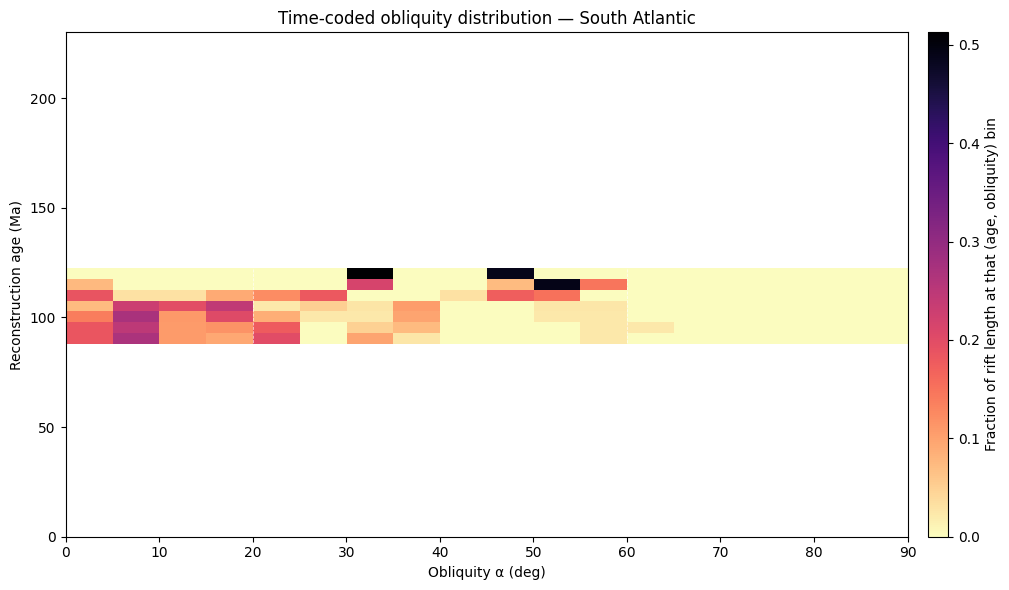

In [8]:
# Sweep the chosen rift through AGES_MA; accumulate obliquity histograms.
def _obliquity_hist_for_age(age_ma, rift_pairs):
    frames = []
    for pair in rift_pairs:
        df = compute_rift_obliquity(cob_by_plate, pair, age_ma)
        if not df.empty:
            frames.append(df)
    if not frames:
        return np.zeros(len(bins) - 1)
    df = pd.concat(frames, ignore_index=True)
    h, _ = np.histogram(df["obliquity_deg"], bins=bins,
                        weights=df["seg_len_km"])
    return h


bins = np.arange(0, 90 + OBLIQUITY_BIN_DEG, OBLIQUITY_BIN_DEG)
rift_pairs_sel = RIFT_SYSTEMS[RIFT_SYSTEM_NAME]
surface = np.zeros((len(AGES_MA), len(bins) - 1))
totlen = np.zeros(len(AGES_MA))
for i, age in enumerate(AGES_MA):
    h = _obliquity_hist_for_age(age, rift_pairs_sel)
    surface[i] = h
    totlen[i] = h.sum()
    print(f"    age {age:>3} Ma  {int(h.sum()):>7,} km total rift length  "
          f"({int((h > 0).sum())} non-empty obliquity bins)")

# Normalise each row by total length so we see the *fractional* distribution
row_norm = np.where(totlen[:, None] > 0, surface / totlen[:, None], np.nan)

fig, ax = plt.subplots(figsize=(11, 6))
extent = [bins[0], bins[-1], AGES_MA[-1], AGES_MA[0]]   # y flipped: old→new top-to-bottom
im = ax.imshow(row_norm, extent=extent, aspect="auto", cmap="magma_r",
                origin="lower", vmin=0, vmax=np.nanmax(row_norm))
ax.axvline(20, color="white", ls="--", lw=0.6, alpha=0.7)
ax.axvline(60, color="white", ls="--", lw=0.6, alpha=0.7)
ax.set_xlabel("Obliquity α (deg)")
ax.set_ylabel("Reconstruction age (Ma)")
ax.set_title(f"Time-coded obliquity distribution — {RIFT_SYSTEM_NAME}")
cbar = plt.colorbar(im, ax=ax, pad=0.02, aspect=25)
cbar.set_label("Fraction of rift length at that (age, obliquity) bin")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### What this surface plot shows

Each **horizontal row** is one snapshot age's obliquity histogram (from §5), row-normalised so a row's colour-integral is 100 %. Time runs from old (bottom) to young (top), so a horizontal band of dark colour tracks an obliquity phase persisting across a time interval.

For the South Atlantic, expect:

- **~140-125 Ma (deep rifting)** — mid-α oblique band (20-60°) dominates the S. Atlantic rift signal.
- **~125-100 Ma (breakup + post-rift)** — rift-length drops abruptly as breakup completes (rows go pale), leaving only strike-slip transform edges.
- **Post-100 Ma** — S. Atlantic is essentially a mid-ocean-ridge system; the shared-COB segments approach zero and the surface goes nearly blank.


## 7. Global rift-length time series


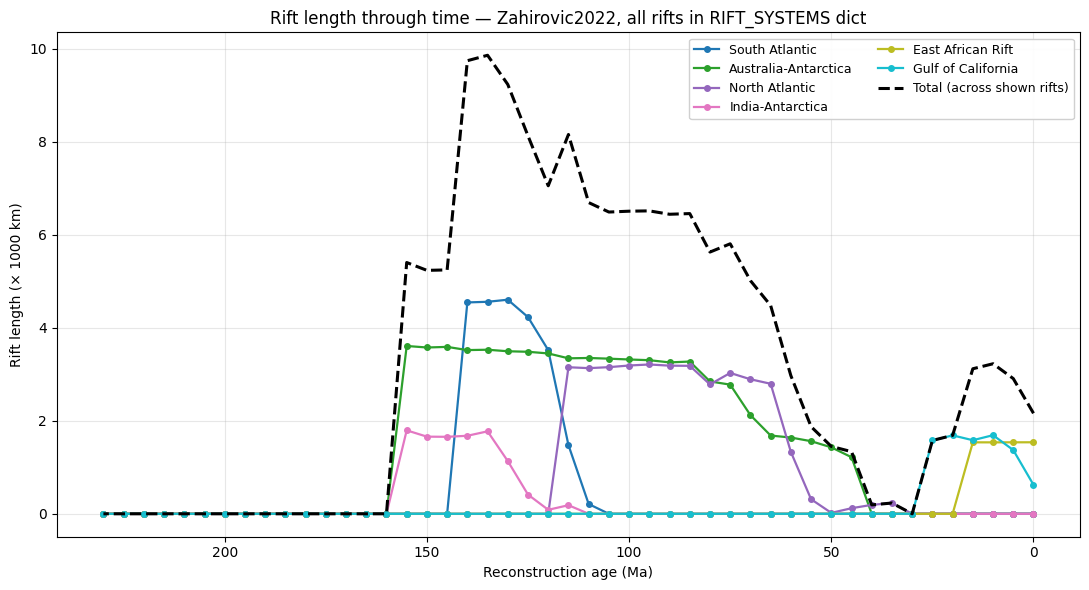

In [9]:
# Loop through ALL rift systems in the RIFT_SYSTEMS dict and sum rift length
# per age. Brune et al. (2017) showed that global rift length exhibits pulses
# associated with supercontinent breakup and correlated with CO₂ degassing.
def _rift_length_all_pairs(age_ma, all_rifts):
    total = 0.0
    per_sys = {}
    for name, pairs in all_rifts.items():
        _tot_sys = 0.0
        for pair in pairs:
            df = compute_rift_obliquity(cob_by_plate, pair, age_ma)
            if not df.empty:
                _tot_sys += float(df["seg_len_km"].sum())
        per_sys[name] = _tot_sys
        total += _tot_sys
    return total, per_sys


ts_rows = []
for age in AGES_MA:
    total, per_sys = _rift_length_all_pairs(age, RIFT_SYSTEMS)
    row = {"age_Ma": age, "total_km": total}
    row.update({f"rift_{k.replace(' ', '_')}_km": v for k, v in per_sys.items()})
    ts_rows.append(row)
ts_df = pd.DataFrame(ts_rows).sort_values("age_Ma")

fig, ax = plt.subplots(figsize=(11, 6))
# Individual rift systems
per_sys_cols = [c for c in ts_df.columns if c.startswith("rift_")]
palette = plt.cm.tab10(np.linspace(0, 1, len(per_sys_cols)))
for col, colr in zip(per_sys_cols, palette):
    label = col.replace("rift_", "").replace("_km", "").replace("_", " ")
    ax.plot(ts_df["age_Ma"], ts_df[col] / 1000,
            color=colr, marker="o", markersize=4, lw=1.6, label=label)
# Total on secondary axis (dashed black)
ax.plot(ts_df["age_Ma"], ts_df["total_km"] / 1000,
        color="black", ls="--", lw=2.2, label="Total (across shown rifts)")
ax.set_xlabel("Reconstruction age (Ma)")
ax.set_ylabel("Rift length (× 1000 km)")
ax.set_title(f"Rift length through time — {MODEL_NAME}, all rifts in RIFT_SYSTEMS dict")
ax.grid(alpha=0.3)
ax.invert_xaxis()
ax.legend(loc="upper right", fontsize=9, framealpha=0.92, ncol=2)
plt.tight_layout()
plt.show()


### What the rift-length time series shows

Each coloured line is one rift system's total shared-COB segment length through time; the dashed black line is the sum. Peaks correspond to periods of active rifting; troughs to periods after breakup when the two flanks have separated beyond the COB polygon overlap zone.

**Global signature to expect**:

- **Late Jurassic / Early Cretaceous (200-130 Ma)** — Pangea breakup peak — S. Atlantic, N. Atlantic, India-Antarctica all active.
- **Mid-late Cretaceous (130-80 Ma)** — Pangea breakup completes; rift lengths taper.
- **Cenozoic (65-0 Ma)** — mostly modern rifts: East African Rift, Gulf of California; total length is a small residual.

The 230-Myr integrated global rift-length curve is what Brune et al. (2017) correlated with volcanic CO₂ degassing — passive-margin extension is a primary volcanic-outgassing regulator through geologic time. Extend the dictionary at the top of the notebook to add more rifts (Adriatic, Amerasian, Woodlark, etc.) for a fuller global time series.


## Extend this

- **Add more rift systems**: The `RIFT_SYSTEMS` dict at the top of the notebook is the only place to edit. Try adding the Woodlark Basin (`[(801, 833)]`), the Adriatic (need to look up modern plate IDs in Z22), or the East African Rift's northern branch. Each new entry automatically feeds the §7 time-series plot.
- **Compare plate models**: Swap `MODEL_NAME` between Zahirovic 2022, Merdith 2021, and Müller 2019 to see how obliquity distributions differ. Merdith 2021 is likely to give slightly higher obliquity in the S. Atlantic (its Iberia-Africa refinement moves that segment more obliquely).
- **Test the plume-mode / slow-mode dichotomy** (Brune 2016 Nature): categorize samples by extension rate and obliquity to see whether they cluster into fast-orthogonal and slow-oblique end-members.
- **Correlate rift-length with CO₂ degassing** (Brune 2017): overlay the global rift-length curve from §7 on top of a Phanerozoic CO₂ proxy (e.g., the Foster et al. 2017 compilation, or the Judd et al. 2024 update).
- **Extend the shapefile**: The bundled S. Brune COB shapefile has 31 continental blocks. To add smaller blocks (e.g., Zealandia sub-blocks), export new polygons from GPlates as `gpml:ClosedContinentalBoundary` features and drop them into the same shapefile with unique `PLATEID1` values.
- **Cross-check against T13 (paleo-σHmax)**: the σHmax orientation predicted from plate motions in T13 should be related to the rift obliquity computed here — orthogonal rifts have σHmax perpendicular to the rift, oblique rifts have σHmax at a diagnostic angle.

## References

Full citations for the Brune et al. papers cited in this notebook:

- **Brune, S., Popov, A.A., Sobolev, S.V. (2012).** Modeling suggests that oblique extension facilitates rifting and continental break-up. *Journal of Geophysical Research: Solid Earth* 117, B08402. https://doi.org/10.1029/2011JB008860
- **Brune, S., Heine, C., Pérez-Gussinyé, M., Sobolev, S.V. (2014).** Rift migration explains continental margin asymmetry and crustal hyper-extension. *Nature Communications* 5, 4014. https://doi.org/10.1038/ncomms5014
- **Brune, S., Williams, S.E., Butterworth, N.P., Müller, R.D. (2016).** Abrupt plate accelerations shape rifted continental margins. *Nature* 536, 201-204. https://doi.org/10.1038/nature18319
- **Brune, S., Williams, S.E., Müller, R.D. (2017).** Potential links between continental rifting, CO₂ degassing and climate change through time. *Nature Geoscience* 10, 941-946. https://doi.org/10.1038/s41561-017-0003-6
- **Brune, S., Williams, S.E., Müller, R.D. (2018).** Oblique rifting: the rule, not the exception. *Solid Earth* 9, 1187-1206. https://doi.org/10.5194/se-9-1187-2018
